# Proyecto DGT

## Preparación de los ficheros de datos: importación de librerías y carga de datos

In [1]:
from pathlib import Path # para manipular rutas del sistema de archivos
import pandas as pd  # para manipulación de datos
import numpy as np  # para realizar operaciones numéricas

import matplotlib.pyplot as plt  # para gráficos
import seaborn as sns  # para gráficos estadísticos

plt.style.use("ggplot")
sns.set_theme()

In [2]:
# Lectura del fichero de datos

# Carpeta donde están los Excel
carpeta = Path(r"C:\Users\U000000\Desktop\varios\ThePower\PROYECTO_FINAL\datos")
fichero = carpeta / f"data_complete_DGT_2014_2024.xlsx"
fichero_final = carpeta / f"data_DGT_2014_2024.xlsx"

df = pd.read_excel(fichero)


## Limpieza de datos

En este punto se realiza una exploración inicial del fichero cargado y se lleva a cabo la limpieza de los datos.
La limpieza de datos incluye el tratamiento de los valores duplicados (en este caso ya se ha comprobado en la carga que no hay duplicados), de los valores nulos, cambiar tipos de datos, selección de columnas o revisar las categorías de las variables.

In [3]:
# Realizamos una exploración inicial de los dos ficheros de datos

df.head(5)

,Año,Código INE,Municipio,Provincia,Comunidad Autónoma,Población Total,Población Hombres,Población Mujeres,Conductores Hombres,Conductoras Mujeres,...,Otros Fallecidos,Otros Heridos Graves,Otros Heridos Leves,Peatones Fallecidos,Peatones Heridos Graves,Peatones Heridos Leves,Nº Accidentes con Víctimas,Fallecidos,Heridos Hospitalizados,Heridos no Hospitalizados
0,2014,1000,Alava ( municipio sin especificar),Araba/Álava,País Vasco,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2014,1001,Alegría-Dulantzi,Araba/Álava,País Vasco,2925.0,1513.0,1412.0,971.0,771.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,2014,1002,Amurrio,Araba/Álava,País Vasco,10239.0,5108.0,5131.0,3663.0,2529.0,...,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,3.0
3,2014,1003,Aramaio,Araba/Álava,País Vasco,1478.0,780.0,698.0,579.0,429.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2014,1004,Artziniega,Araba/Álava,País Vasco,1818.0,905.0,913.0,617.0,479.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [4]:
print(df.columns.tolist())

# Definimos las columnas que queremos conservar
columnas = [
    "Año",
    "Código INE",
    "Municipio",
    "Provincia",
    "Comunidad Autónoma",
    "Población Total",
    "Población Hombres",
    "Población Mujeres",
    "Conductores Hombres",
    "Conductoras Mujeres",
    "Censo Conductores",
    "Parque Ciclomotores",
    "Parque Motocicletas",
    "Parque Turismos",
    "Parque Furgonetas",
    "Parque Camiones",
    "Parque Total",
    "Motocicletas sin ITV (<25 años)",
    "Turismos sin ITV (<25 años)",
    "Resto de Vehículos sin ITV (<25 años)",
    "Antigüedad Media del Parque (<25 años)",
    "Antigüedad Media de Ciclomotores",
    "Antigüedad Media de Motocicletas",
    "Antigüedad Media de Turismos",
    "Antigüedad Media de Furgonetas",
    "Antigüedad Media de Camiones",
    "Gasolina",
    "Diesel",
    "Electrificado",
    "GLP (Gas Licuado del Petroleo)",
    "GNL (Gas Natural Licuado)",
    "Otros Tipos de Propulsión",
    "Distintivo B",
    "Distintivo C",
    "Distintivo ECO",
    "Distintivo 0",
    "Sin Distintivo",
    "Total Campañas",
    "Total Sanciones con Puntos",
    "Total Puntos Detraídos",
    "Velocidad (2 puntos)",
    "Velocidad (3 puntos)",
    "Velocidad (4 puntos)",
    "Velocidad (6 puntos)",
    "Alcohol (4 puntos)",
    "Alcohol (6 puntos)",
    "Drogas (6 puntos)",
    "Casco, Cinturón, SRI (3 puntos)",
    "Casco, Cinturón, SRI (4 puntos)",
    "Casco, Cinturón, SRI (6 puntos)",
    "Móvil (3 puntos)",
    "Móvil (4 puntos)",
    "Móvil (6 puntos)",
    "Semáforo (3 puntos)",
    "Semáforo (4 puntos)",
    "Semáforo (6 puntos)",
    "Otra (3 puntos)",
    "Otra (4 puntos)",
    "Otra (6 puntos)",
    "Bicicletas Fallecidos",
    "Bicicletas Heridos Graves",
    "Bicicletas Heridos Leves",
    "Ciclomotores Fallecidos",
    "Ciclomotores Heridos Graves",
    "Ciclomotores Heridos Leves",
    "Motocicletas Fallecidos",
    "Motocicletas Heridos Graves",
    "Motocicletas Heridos Leves",
    "Turismos Fallecidos",
    "Turismos Heridos Graves",
    "Turismos Heridos Leves",
    "Furgonetas Fallecidos",
    "Furgonetas Heridos Graves",
    "Furgonetas Heridos Leves",
    "Camiones Fallecidos",
    "Camiones Heridos Graves",
    "Camiones Heridos Leves",
    "Autobús Fallecidos",
    "Autobús Heridos Graves",
    "Autobús Heridos Leves",
    "Otros Fallecidos",
    "Otros Heridos Graves",
    "Otros Heridos Leves",
    "Peatones Fallecidos",
    "Peatones Heridos Graves",
    "Peatones Heridos Leves",
    "Nº Accidentes con Víctimas",
    "Fallecidos",
    "Heridos Hospitalizados",
    "Heridos no Hospitalizados"
]

# Creamos el subconjunto
df_subconjunto = df[columnas]

# 4. Guardar en un nuevo Excel
df_subconjunto.to_excel(fichero_final, index=False)

print("\nFichero final creado correctamente.")
print(f"Fichero: {fichero_final}")
print(f"Filas: {len(df_subconjunto):,}")
print(f"Columnas: {len(df_subconjunto.columns)}")

['Año', 'Código INE', 'Municipio', 'Provincia', 'Comunidad Autónoma', 'Población Total', 'Población Hombres', 'Población Mujeres', 'Conductores Hombres', 'Conductoras Mujeres', 'Censo Conductores', 'Parque Ciclomotores', 'Parque Motocicletas', 'Parque Turismos', 'Parque Furgonetas', 'Parque Camiones', 'Parque Total', 'Motocicletas sin ITV (<25 años)', 'Turismos sin ITV (<25 años)', 'Resto de Vehículos sin ITV (<25 años)', 'Parque Ciclomotores (<25 años)', 'Parque Ciclomotores (<15 años)', 'Parque Ciclomotores (<8 años)', 'Parque Ciclomotores (<4 años)', 'Parque Motocicletas (<25 años)', 'Parque Motocicletas (<15 años)', 'Parque Motocicletas (<8 años)', 'Parque Motocicletas (<4 años)', 'Parque Turismos (<25 años)', 'Parque Turismos (<15 años)', 'Parque Turismos (<8 años)', 'Parque Turismos (<4 años)', 'Parque Furgonetas (<25 años)', 'Parque Furgonetas (<15 años)', 'Parque Furgonetas (<8 años)', 'Parque Furgonetas (<4 años)', 'Parque Camiones (<25 años)', 'Parque Camiones (<15 años)', 'P

In [5]:
# Leemos el fichero de datos

dgt = pd.read_excel(fichero_final)
dgt.info()

<class 'pandas.DataFrame'>
RangeIndex: 90156 entries, 0 to 90155
Data columns (total 90 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Año                                     90156 non-null  int64  
 1   Código INE                              90156 non-null  int64  
 2   Municipio                               90156 non-null  str    
 3   Provincia                               90156 non-null  str    
 4   Comunidad Autónoma                      90156 non-null  str    
 5   Población Total                         89395 non-null  float64
 6   Población Hombres                       89395 non-null  float64
 7   Población Mujeres                       89395 non-null  float64
 8   Conductores Hombres                     89815 non-null  float64
 9   Conductoras Mujeres                     89815 non-null  float64
 10  Censo Conductores                       89815 non-null  float64
 11  

In [6]:
# Mostramos una descripción de las variables del dichero de datos, para hacernos una idea general

dgt.describe().T

,count,mean,std,min,25%,50%,75%,max
Año,90156.0,2019.000000,3.162295,2014.0,2016.00,2019.0,2022.00,2024.0
Código INE,90156.0,26778.144583,14887.506830,1000.0,13083.75,26017.5,41019.25,52001.0
Población Total,89395.0,5808.188545,47428.968862,2.0,157.00,532.0,2418.00,3422416.0
Población Hombres,89395.0,2847.774204,22361.729410,2.0,86.00,279.0,1220.00,1602924.0
Población Mujeres,89395.0,2960.414341,25074.242040,0.0,71.00,253.0,1194.00,1819492.0
...,...,...,...,...,...,...,...,...
Peatones Heridos Leves,76274.0,1.545887,21.253126,0.0,0.00,0.0,0.00,1440.0
Nº Accidentes con Víctimas,76274.0,8.946600,158.595757,0.0,0.00,0.0,1.00,10679.0
Fallecidos,76274.0,0.068372,0.733249,0.0,0.00,0.0,0.00,51.0
Heridos Hospitalizados,76274.0,0.652739,10.306115,0.0,0.00,0.0,0.00,1088.0


In [7]:
# Creamos una función para guardar gráficos

def guardar_grafico(nombre):
    plt.tight_layout() # Añadimos esta línea de código para evitar que se corten los títulos o las etiquetas de los ejes
    plt.savefig(f"C:/Users/U000000/Desktop/varios/ThePower/PROYECTO_FINAL/images/{nombre}.png", dpi=300, bbox_inches="tight")
    plt.show()

## Nivel 1: España por año

¿Cómo ha evolucionado la población, la movilidad y la seguridad vial en España entre 2014 y 2024?
Para responder esta pregunta, agregamos los datos municipales para cada año. 
En esta ocasión solo vamos a agregar aquellas variables que no sean medias. Si quisiéramos profundizar en el análisis nacional, y contar con estas variables, tendríamos que ponderar la suma para tener en cuenta la población de cada municipio.

In [8]:
# Agregación de los datos municipales a nivel nacional (España) por año

dgt_anual = dgt.groupby("Año").agg({
    
    # Población y conductores
    "Población Total": "sum",
    "Población Hombres": "sum",
    "Población Mujeres": "sum",
    "Conductores Hombres": "sum",
    "Conductoras Mujeres": "sum",
    "Censo Conductores": "sum",
    
    # Parque de vehículos
    "Parque Ciclomotores": "sum",
    "Parque Motocicletas": "sum",
    "Parque Turismos": "sum",
    "Parque Furgonetas": "sum",
    "Parque Camiones": "sum",
    "Parque Total": "sum",
    
    # Vehículos sin ITV
    "Motocicletas sin ITV (<25 años)": "sum",
    "Turismos sin ITV (<25 años)": "sum",
    "Resto de Vehículos sin ITV (<25 años)": "sum",
    
    # Propulsión
    "Gasolina": "sum",
    "Diesel": "sum",
    "Electrificado": "sum",
    "GLP (Gas Licuado del Petroleo)": "sum",
    "GNL (Gas Natural Licuado)": "sum",
    "Otros Tipos de Propulsión": "sum",
    
    # Distintivo ambiental
    "Distintivo B": "sum",
    "Distintivo C": "sum",
    "Distintivo ECO": "sum",
    "Distintivo 0": "sum",
    "Sin Distintivo": "sum",
    
    # Campañas y sanciones
    "Total Campañas": "sum",
    "Total Sanciones con Puntos": "sum",
    "Total Puntos Detraídos": "sum",
    
    # Sanciones por tipo
    "Velocidad (2 puntos)": "sum",
    "Velocidad (3 puntos)": "sum",
    "Velocidad (4 puntos)": "sum",
    "Velocidad (6 puntos)": "sum",
    "Alcohol (4 puntos)": "sum",
    "Alcohol (6 puntos)": "sum",
    "Drogas (6 puntos)": "sum",
    "Casco, Cinturón, SRI (3 puntos)": "sum",
    "Casco, Cinturón, SRI (4 puntos)": "sum",
    "Casco, Cinturón, SRI (6 puntos)": "sum",
    "Móvil (3 puntos)": "sum",
    "Móvil (4 puntos)": "sum",
    "Móvil (6 puntos)": "sum",
    "Semáforo (3 puntos)": "sum",
    "Semáforo (4 puntos)": "sum",
    "Semáforo (6 puntos)": "sum",
    "Otra (3 puntos)": "sum",
    "Otra (4 puntos)": "sum",
    "Otra (6 puntos)": "sum",
    
    # Siniestralidad por tipo de usuario/vehículo
    "Bicicletas Fallecidos": "sum",
    "Bicicletas Heridos Graves": "sum",
    "Bicicletas Heridos Leves": "sum",
    "Ciclomotores Fallecidos": "sum",
    "Ciclomotores Heridos Graves": "sum",
    "Ciclomotores Heridos Leves": "sum",
    "Motocicletas Fallecidos": "sum",
    "Motocicletas Heridos Graves": "sum",
    "Motocicletas Heridos Leves": "sum",
    "Turismos Fallecidos": "sum",
    "Turismos Heridos Graves": "sum",
    "Turismos Heridos Leves": "sum",
    "Furgonetas Fallecidos": "sum",
    "Furgonetas Heridos Graves": "sum",
    "Furgonetas Heridos Leves": "sum",
    "Camiones Fallecidos": "sum",
    "Camiones Heridos Graves": "sum",
    "Camiones Heridos Leves": "sum",
    "Autobús Fallecidos": "sum",
    "Autobús Heridos Graves": "sum",
    "Autobús Heridos Leves": "sum",
    "Otros Fallecidos": "sum",
    "Otros Heridos Graves": "sum",
    "Otros Heridos Leves": "sum",
    "Peatones Fallecidos": "sum",
    "Peatones Heridos Graves": "sum",
    "Peatones Heridos Leves": "sum",
    
    # Siniestralidad general
    "Nº Accidentes con Víctimas": "sum",
    "Fallecidos": "sum",
    "Heridos Hospitalizados": "sum",
    "Heridos no Hospitalizados": "sum"
}).reset_index()

In [9]:
#Vemos las columnas del fichero de datos que hemos creado

dgt_anual.info()

<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 80 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Año                                    11 non-null     int64  
 1   Población Total                        11 non-null     float64
 2   Población Hombres                      11 non-null     float64
 3   Población Mujeres                      11 non-null     float64
 4   Conductores Hombres                    11 non-null     float64
 5   Conductoras Mujeres                    11 non-null     float64
 6   Censo Conductores                      11 non-null     float64
 7   Parque Ciclomotores                    11 non-null     float64
 8   Parque Motocicletas                    11 non-null     float64
 9   Parque Turismos                        11 non-null     float64
 10  Parque Furgonetas                      11 non-null     float64
 11  Parque Camiones    

In [10]:
# Fichero con los datos anuales para España

dgt_anual

,Año,Población Total,Población Hombres,Población Mujeres,Conductores Hombres,Conductoras Mujeres,Censo Conductores,Parque Ciclomotores,Parque Motocicletas,Parque Turismos,...,Otros Fallecidos,Otros Heridos Graves,Otros Heridos Leves,Peatones Fallecidos,Peatones Heridos Graves,Peatones Heridos Leves,Nº Accidentes con Víctimas,Fallecidos,Heridos Hospitalizados,Heridos no Hospitalizados
0,2014,46771341.0,22985676.0,23785665.0,15347999.0,10869203.0,26217202.0,2061044.0,2972165.0,22029512.0,...,3.0,43.0,389.0,204.0,1649.0,10091.0,56423.0,441.0,4740.0,68365.0
1,2015,46624382.0,22890383.0,23733999.0,15362190.0,10987846.0,26350036.0,2023211.0,3079463.0,22355549.0,...,3.0,63.0,511.0,247.0,1763.0,11673.0,63198.0,441.0,4751.0,76924.0
2,2016,46557008.0,22843610.0,23713398.0,15377544.0,11136484.0,26514028.0,1987470.0,3211474.0,22876830.0,...,11.0,69.0,616.0,252.0,1719.0,12239.0,65641.0,519.0,4705.0,79256.0
3,2017,46572132.0,22832861.0,23739271.0,15393675.0,11255779.0,26649454.0,1961523.0,3327048.0,23500401.0,...,9.0,57.0,432.0,248.0,1717.0,11790.0,64740.0,509.0,4780.0,77276.0
4,2018,46722980.0,22896602.0,23826378.0,15445667.0,11408087.0,26853754.0,1933445.0,3459722.0,24074151.0,...,11.0,56.0,723.0,237.0,1643.0,11665.0,64407.0,489.0,4484.0,76550.0
5,2019,47026208.0,23042428.0,23983780.0,15624690.0,11686326.0,27311016.0,1908492.0,3607226.0,24558126.0,...,20.0,139.0,2546.0,247.0,1483.0,11772.0,66741.0,519.0,4310.0,79338.0
6,2020,47450795.0,23255590.0,24195205.0,15523070.0,11682965.0,27206035.0,1891754.0,3735920.0,24716898.0,...,15.0,161.0,2241.0,153.0,971.0,7309.0,46348.0,395.0,3320.0,53635.0
7,2021,47385107.0,23222953.0,24162154.0,15602779.0,11824780.0,27427559.0,1868056.0,3866220.0,24940969.0,...,13.0,271.0,4204.0,183.0,1237.0,8979.0,58082.0,417.0,4142.0,67737.0
8,2022,47475420.0,23265381.0,24210039.0,15699995.0,11964080.0,27664075.0,1842501.0,4006804.0,25222554.0,...,18.0,384.0,5775.0,213.0,1449.0,10660.0,64616.0,473.0,4610.0,74530.0
9,2023,48022515.0,23516666.0,24505849.0,15816977.0,12097595.0,27914572.0,1815623.0,4162850.0,25356594.0,...,27.0,415.0,6690.0,223.0,1569.0,10965.0,65976.0,518.0,4920.0,76520.0


In [11]:
# Creamos nuevas columnas para poder hacer una comparación anual a partir de indicadores

# Vehículos por cada 1.000 habitantes
dgt_anual["Vehiculos_por_1000_hab"] = (
    dgt_anual["Parque Total"]
    / dgt_anual["Población Total"]
    * 1000
)

# Accidentes por cada 1.000 habitantes
dgt_anual["Accidentes_por_1000_hab"] = (
    dgt_anual["Nº Accidentes con Víctimas"]
    / dgt_anual["Población Total"]
    * 1000
)

# Fallecidos por cada 100.000 habitantes,
dgt_anual["Fallecidos_por_100000_hab"] = (
    dgt_anual["Fallecidos"]
    / dgt_anual["Población Total"]
    * 100000
)


# Sanciones por cada 1.000 conductores
dgt_anual["Sanciones_por_1000_conductores"] = (
    dgt_anual["Total Sanciones con Puntos"]
    / dgt_anual["Censo Conductores"]
    * 1000
)


# Porcentaje de parque electrificado
dgt_anual["Pct_Electrificado"] = (
    dgt_anual["Electrificado"]
    / dgt_anual["Parque Total"]
    * 100
)


In [12]:
# Preparamos los indicadores en una tabla

indicadores = [
    "Año",
    "Vehiculos_por_1000_hab",
    "Accidentes_por_1000_hab",
    "Fallecidos_por_100000_hab",
    "Sanciones_por_1000_conductores",
    "Pct_Electrificado"
]

tabla_indicadores = dgt_anual[indicadores].copy()

tabla_indicadores


,Año,Vehiculos_por_1000_hab,Accidentes_por_1000_hab,Fallecidos_por_100000_hab,Sanciones_por_1000_conductores,Pct_Electrificado
0,2014,706.353299,1.206358,0.942885,17.314472,0.058098
1,2015,716.639933,1.355471,0.945857,18.081417,0.068605
2,2016,732.306294,1.409906,1.114762,16.326452,0.085396
3,2017,749.171779,1.390102,1.092928,16.446866,0.120933
4,2018,763.295214,1.378487,1.046594,16.536049,0.177109
5,2019,772.830397,1.419230,1.103640,14.693631,0.252850
6,2020,772.525666,0.976759,0.832441,11.945401,0.341687
7,2021,781.825057,1.225744,0.880023,15.335707,0.436693
8,2022,790.112947,1.361041,0.996305,16.225701,0.561226
9,2023,789.022836,1.373856,1.078661,16.433675,0.751778


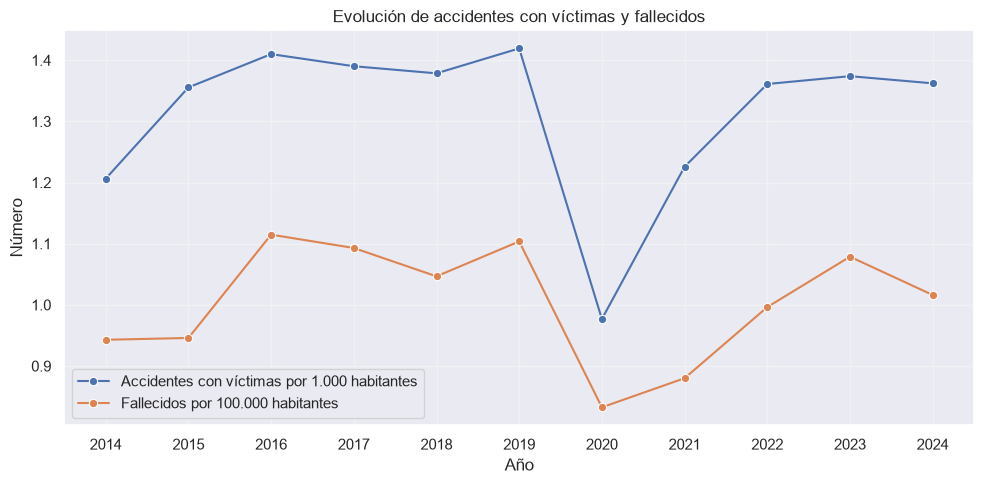

In [13]:
# Gráfico: accidentes por 1.000 habitantes

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=dgt_anual,
    x="Año",
    y="Accidentes_por_1000_hab",
    marker="o",
    label="Accidentes con víctimas por 1.000 habitantes"
)

sns.lineplot(
    data=dgt_anual,
    x="Año",
    y="Fallecidos_por_100000_hab",
    marker="o",
    label="Fallecidos por 100.000 habitantes"
)


plt.title("Evolución de accidentes con víctimas y fallecidos")
plt.xlabel("Año")
plt.ylabel("Número")
plt.xticks(dgt_anual["Año"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

guardar_grafico("evo_accidentes_fallecidos")

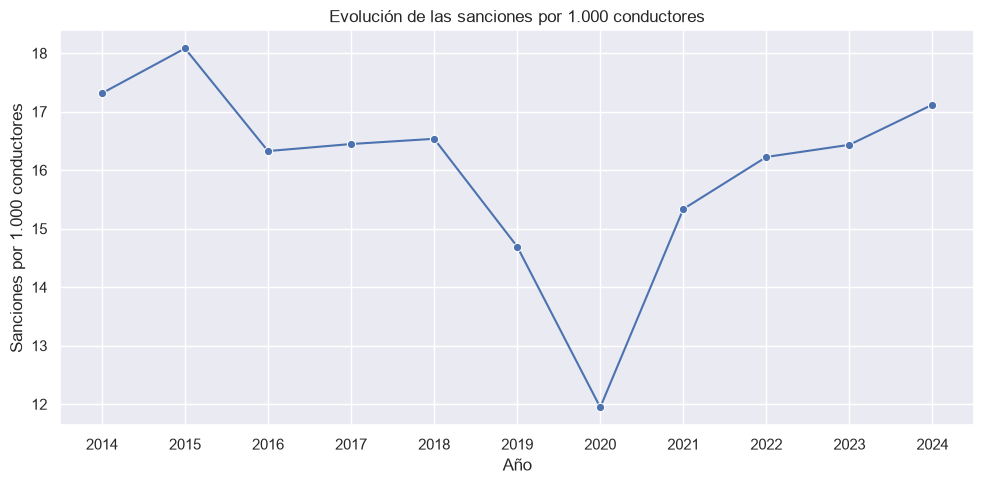

In [14]:
# Gráfico de sanciones por 1.000 conductores

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=dgt_anual,
    x="Año",
    y="Sanciones_por_1000_conductores",
    marker="o"
)

plt.title("Evolución de las sanciones por 1.000 conductores")
plt.xlabel("Año")
plt.ylabel("Sanciones por 1.000 conductores")
plt.xticks(dgt_anual["Año"])
plt.tight_layout()

guardar_grafico("evo_sanciones")


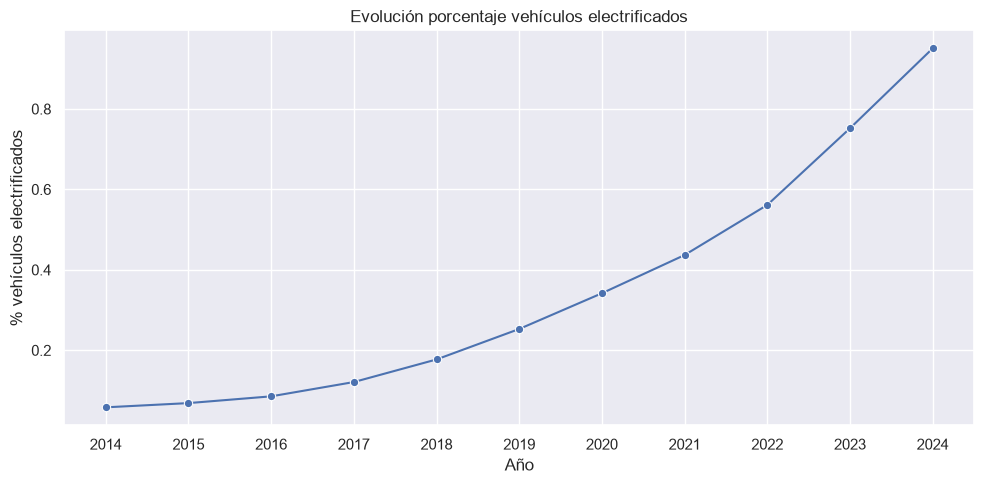

In [15]:
# Gráfico de % de vehículos electrificados

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=dgt_anual,
    x="Año",
    y="Pct_Electrificado",
    marker="o"
)

plt.title("Evolución porcentaje vehículos electrificados")
plt.xlabel("Año")
plt.ylabel("% vehículos electrificados")
plt.xticks(dgt_anual["Año"])
plt.tight_layout()

guardar_grafico("evo_electrificados")


In [16]:
# Variación 2014-2024 en los indicadores. Creamos una tabla donde comparamos la evolución entre 2014 y 2024. 

comparacion = tabla_indicadores.set_index("Año").loc[[2014, 2024]].T

comparacion["Variacion_%"] = (
    (comparacion[2024] - comparacion[2014])
    / comparacion[2014] * 100
)

comparacion.round(2)

Año,2014,2024,Variacion_%
Vehiculos_por_1000_hab,706.35,778.82,10.26
Accidentes_por_1000_hab,1.21,1.36,12.91
Fallecidos_por_100000_hab,0.94,1.02,7.77
Sanciones_por_1000_conductores,17.31,17.12,-1.12
Pct_Electrificado,0.06,0.95,1535.92


In [17]:
# Guardamos el fichero con los datos nacionales

ruta_esp = carpeta / "dgt_esp_2014_2024.xlsx"

dgt_anual.to_excel(
    ruta_esp,
    index=False
)

print(f"Fichero guardado en: {ruta_esp}")

Fichero guardado en: C:\Users\U000000\Desktop\varios\ThePower\PROYECTO_FINAL\datos\dgt_esp_2014_2024.xlsx


## Nivel 2: Comunidades Autónomas

¿Existen diferencias territoriales entre comunidades autónomas? Antes de profundizar a nivel municipal, podemos detectar diferencias entre las comunidades autónomas a lo largo de los años.
En esta ocasión agrupamos por año y CCAA (están incluidas Ceuta y Melilla), y nos quedamos con un número de variables más reducido. Vamos a hacer el mismo análisis que a nivel nacional.

Obtenemos un fichero con 209 filas: 19 comunidades autónomas y 11 años.
Para realizar el análisis, filtramos por año (en nuestro caso, 2024).

In [18]:
# Vemos cuántas comunidades autónomas diferentes hay

dgt["Comunidad Autónoma"].unique()

<StringArray>
[                  'País Vasco',           'Castilla-La Mancha',
         'Comunitat Valenciana',                    'Andalucía',
              'Castilla y León',                  'Extremadura',
              'Balears (Illes)',                     'Cataluña',
                      'Galicia',                       'Aragón',
                   'Rioja (La)',        'Madrid (Comunidad de)',
           'Murcia (Región de)', 'Navarra (Comunidad Foral de)',
     'Asturias (Principado de)',                     'Canarias',
                    'Cantabria',                        'Ceuta',
                      'Melilla']
Length: 19, dtype: str

In [19]:
# Determinamos las columnas que queremos quedarnos para los datos de comunidades autónomas y creamos el dataset dgt_ccaa

columnas_suma = [
    # Población y conductores
    "Población Total",
    "Censo Conductores",

    # Parque de vehículos
    "Parque Ciclomotores",
    "Parque Motocicletas",
    "Parque Turismos",
    "Parque Furgonetas",
    "Parque Camiones",
    "Parque Total",


    # ITV
    "Motocicletas sin ITV (<25 años)",
    "Turismos sin ITV (<25 años)",
    "Resto de Vehículos sin ITV (<25 años)",

    # Propulsión
    "Gasolina",
    "Diesel",
    "Electrificado",

    # Distintivos ambientales
    "Distintivo 0",
    "Distintivo ECO",
    "Distintivo B",
    "Distintivo C",
    "Sin Distintivo",

    # Campañas, sanciones y puntos
    "Total Campañas",
    "Total Puntos Detraídos",
    "Total Sanciones con Puntos",
    
    
    # Sanciones por tipo
    "Velocidad (2 puntos)",
    "Velocidad (3 puntos)",
    "Velocidad (4 puntos)",
    "Velocidad (6 puntos)",
    "Alcohol (4 puntos)",
    "Alcohol (6 puntos)",
    "Drogas (6 puntos)",
    "Casco, Cinturón, SRI (3 puntos)",
    "Casco, Cinturón, SRI (4 puntos)",
    "Casco, Cinturón, SRI (6 puntos)",
    "Móvil (3 puntos)",
    "Móvil (4 puntos)",
    "Móvil (6 puntos)",
    "Semáforo (3 puntos)",
    "Semáforo (4 puntos)",
    "Semáforo (6 puntos)",
    "Otra (3 puntos)",
    "Otra (4 puntos)",
    "Otra (6 puntos)",


    # Accidentes y víctimas
    "Nº Accidentes con Víctimas",
    "Fallecidos",
    "Heridos Hospitalizados",
    "Heridos no Hospitalizados"
]

dgt_ccaa = (
    dgt
    .groupby(["Comunidad Autónoma", "Año"], as_index=False)[columnas_suma]
    .sum()
)

In [20]:
# Resumen del dataset dgt_ccaa que hemos creado

dgt_ccaa

,Comunidad Autónoma,Año,Población Total,Censo Conductores,Parque Ciclomotores,Parque Motocicletas,Parque Turismos,Parque Furgonetas,Parque Camiones,Parque Total,...,Semáforo (3 puntos),Semáforo (4 puntos),Semáforo (6 puntos),Otra (3 puntos),Otra (4 puntos),Otra (6 puntos),Nº Accidentes con Víctimas,Fallecidos,Heridos Hospitalizados,Heridos no Hospitalizados
0,Andalucía,2014,8402305.0,4726168.0,621831.0,558262.0,3736682.0,394482.0,461721.0,5955970.0,...,0.0,57528.0,0.0,11805.0,9396.0,8352.0,9256.0,74.0,593.0,12124.0
1,Andalucía,2015,8399043.0,4746803.0,610452.0,578622.0,3783541.0,396530.0,460416.0,6007993.0,...,0.0,57976.0,0.0,18708.0,10416.0,10170.0,10928.0,79.0,573.0,14556.0
2,Andalucía,2016,8388107.0,4776870.0,599350.0,603161.0,3869264.0,402490.0,459760.0,6119424.0,...,0.0,43268.0,0.0,2439.0,9680.0,9162.0,10258.0,97.0,678.0,13443.0
3,Andalucía,2017,8379820.0,4792867.0,590606.0,627879.0,3977352.0,403152.0,466034.0,6257317.0,...,0.0,33140.0,0.0,2421.0,10668.0,9096.0,10153.0,87.0,655.0,12962.0
4,Andalucía,2018,8384408.0,4827589.0,580947.0,655261.0,4080704.0,412476.0,462897.0,6390680.0,...,0.0,32404.0,0.0,1860.0,10536.0,8532.0,11286.0,87.0,617.0,14419.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,Rioja (La),2020,319914.0,186418.0,9141.0,18161.0,152280.0,18185.0,20023.0,228091.0,...,0.0,804.0,0.0,57.0,412.0,1224.0,247.0,0.0,23.0,277.0
205,Rioja (La),2021,319796.0,187363.0,9101.0,19057.0,153361.0,18443.0,19664.0,230239.0,...,0.0,884.0,0.0,81.0,612.0,1410.0,353.0,3.0,33.0,379.0
206,Rioja (La),2022,319892.0,188160.0,9044.0,19718.0,154610.0,18670.0,19471.0,232503.0,...,0.0,272.0,0.0,330.0,356.0,888.0,402.0,3.0,26.0,436.0
207,Rioja (La),2023,322490.0,189207.0,9006.0,20552.0,156146.0,19045.0,19379.0,235347.0,...,0.0,248.0,0.0,129.0,444.0,1170.0,460.0,1.0,44.0,506.0


In [21]:
# Comprobamos que la agregación es correcta

print("Filas:", len(dgt_ccaa))
print("Comunidades:", dgt_ccaa["Comunidad Autónoma"].nunique())
print("Años:", dgt_ccaa["Año"].nunique())

dgt_ccaa.groupby("Año")["Comunidad Autónoma"].nunique()

Filas: 209
Comunidades: 19
Años: 11


Año
2014    19
2015    19
2016    19
2017    19
2018    19
2019    19
2020    19
2021    19
2022    19
2023    19
2024    19
Name: Comunidad Autónoma, dtype: int64

In [22]:
# Comprobamos que no hay duplicados

dgt_ccaa.duplicated(
    ["Comunidad Autónoma", "Año"]
).sum()

np.int64(0)

In [23]:
# Creamos nuevas columnas para poder hacer una comparación anual a partir de indicadores

dgt_ccaa["Vehiculos_por_1000_hab"] = (
    dgt_ccaa["Parque Total"]
    .div(dgt_ccaa["Población Total"])
    * 1000
)

dgt_ccaa["Accidentes_por_1000_hab"] = (
    dgt_ccaa["Nº Accidentes con Víctimas"]
    .div(dgt_ccaa["Población Total"])
    * 1000
)

dgt_ccaa["Fallecidos_por_100000_hab"] = (
    dgt_ccaa["Fallecidos"]
    .div(dgt_ccaa["Población Total"])
    * 100000
)

dgt_ccaa["Sanciones_por_1000_conductores"] = (
    dgt_ccaa["Total Sanciones con Puntos"]
    .div(dgt_ccaa["Censo Conductores"])
    * 1000
)

dgt_ccaa["Pct_Electrificado"] = (
    dgt_ccaa["Electrificado"]
    .div(dgt_ccaa["Parque Total"])
    * 100
)

dgt_ccaa["Pct_Diesel"] = (
    dgt_ccaa["Diesel"]
    .div(dgt_ccaa["Parque Total"])
    * 100
)

dgt_ccaa["Pct_Gasolina"] = (
    dgt_ccaa["Gasolina"]
    .div(dgt_ccaa["Parque Total"])
    * 100
)

In [24]:
# Guardamos el fichero de CCAA

ruta_ccaa = carpeta / "dgt_ccaa_2014_2024.xlsx"

dgt_ccaa.to_excel(
    ruta_ccaa,
    index=False
)

print(f"Fichero guardado en: {ruta_ccaa}")

Fichero guardado en: C:\Users\U000000\Desktop\varios\ThePower\PROYECTO_FINAL\datos\dgt_ccaa_2014_2024.xlsx


In [25]:
# Año que queremos analizar
año_ranking = 2024

# Indicadores que queremos mostrar
indicadores = [
    "Población Total",
    "Censo Conductores",
    "Parque Total",
    "Nº Accidentes con Víctimas",
    "Fallecidos",
    "Total Sanciones con Puntos",
    "Vehiculos_por_1000_hab",
    "Accidentes_por_1000_hab",
    "Fallecidos_por_100000_hab",
    "Sanciones_por_1000_conductores",
    "Pct_Electrificado",
    "Pct_Diesel",
    "Pct_Gasolina"
]

# Crear tabla
tabla_ccaa = (
    dgt_ccaa[
        dgt_ccaa["Año"] == año_ranking
    ][
        ["Comunidad Autónoma"] + indicadores
    ]
    .reset_index(drop=True)
)

indicador_orden = "Sanciones_por_1000_conductores"

tabla_ccaa_ordenada = tabla_ccaa.sort_values(
    indicador_orden,
    ascending=False
)

tabla_ccaa_ordenada

,Comunidad Autónoma,Población Total,Censo Conductores,Parque Total,Nº Accidentes con Víctimas,Fallecidos,Total Sanciones con Puntos,Vehiculos_por_1000_hab,Accidentes_por_1000_hab,Fallecidos_por_100000_hab,Sanciones_por_1000_conductores,Pct_Electrificado,Pct_Diesel,Pct_Gasolina
13,Madrid (Comunidad de),7009268.0,3792126.0,5581287.0,11564.0,52.0,114218.0,796.272450,1.649816,0.741875,30.119780,2.224971,45.934692,49.465168
8,Cataluña,8012231.0,4381813.0,5597285.0,15361.0,95.0,99515.0,698.592564,1.917194,1.185687,22.710919,1.286445,39.173028,57.210719
3,Balears (Illes),1231768.0,705419.0,1174452.0,1586.0,12.0,12611.0,953.468510,1.287580,0.974209,17.877318,1.122822,33.366029,64.371469
9,Ceuta,83179.0,41615.0,66229.0,287.0,1.0,736.0,796.222604,3.450390,1.202227,17.685931,0.256685,37.371846,61.809781
14,Melilla,85985.0,45515.0,72212.0,412.0,1.0,746.0,839.820899,4.791533,1.162994,16.390201,0.405750,45.295796,53.402482
2,Asturias (Principado de),1009599.0,605972.0,741006.0,1118.0,15.0,9830.0,733.960711,1.107370,1.485738,16.221872,0.472466,53.889172,43.705989
18,Rioja (La),324184.0,190927.0,237322.0,474.0,5.0,2932.0,732.059571,1.462133,1.542334,15.356655,0.568005,55.084232,42.220696
6,Castilla y León,2391682.0,1479100.0,1980534.0,1927.0,29.0,21930.0,828.092531,0.805709,1.212536,14.826584,0.393278,56.512890,40.731338
7,Castilla-La Mancha,2104433.0,1284732.0,1816804.0,1295.0,13.0,18756.0,863.322330,0.615368,0.617744,14.599154,0.486128,59.540930,37.617817
1,Aragón,1351591.0,769150.0,986592.0,1259.0,15.0,11020.0,729.948631,0.931495,1.109803,14.327504,0.615351,52.192497,43.888761


In [26]:
# Creamos indicadores y la tabla para analizar el top5 de las comunidades autónomas en los diferentes indicadores en 2024

indicadores_top5 = {
    "Vehiculos_por_1000_hab": "Vehículos / 1.000 hab.",
    "Accidentes_por_1000_hab": "Accidentes / 1.000 hab.",
    "Fallecidos_por_100000_hab": "Fallecidos / 100.000 hab.",
    "Sanciones_por_1000_conductores": "Sanciones / 1.000 conductores",
    "Pct_Electrificado": "% Electrificado"
}

top5 = pd.DataFrame()

for indicador, nombre in indicadores_top5.items():

    top = (
        tabla_ccaa[
            ["Comunidad Autónoma", indicador]
        ]
        .dropna()
        .sort_values(indicador, ascending=False)
        .head(5)
        .reset_index(drop=True)
    )

    valores = top[indicador].map(lambda x: f"{x:.2f}")

    if indicador == "Pct_Electrificado":
        valores = valores + "%"

    top5[nombre] = (
        top["Comunidad Autónoma"]
        + " — "
        + valores
    )

top5.index = range(1, 6)
top5.index.name = "Puesto"

top5


,Vehículos / 1.000 hab.,Accidentes / 1.000 hab.,Fallecidos / 100.000 hab.,Sanciones / 1.000 conductores,% Electrificado
Puesto,,,,,
1,Balears (Illes) — 953.47,Melilla — 4.79,Murcia (Región de) — 1.66,Madrid (Comunidad de) — 30.12,Madrid (Comunidad de) — 2.22%
2,Extremadura — 898.64,Ceuta — 3.45,Rioja (La) — 1.54,Cataluña — 22.71,Cataluña — 1.29%
3,Castilla-La Mancha — 863.32,Murcia (Región de) — 2.01,Asturias (Principado de) — 1.49,Balears (Illes) — 17.88,Balears (Illes) — 1.12%
4,Canarias — 859.56,Cataluña — 1.92,Castilla y León — 1.21,Ceuta — 17.69,Navarra (Comunidad Foral de) — 0.90%
5,Melilla — 839.82,Madrid (Comunidad de) — 1.65,Andalucía — 1.20,Melilla — 16.39,Canarias — 0.87%


In [27]:
# Creamos indicadores y la tabla para analizar el bottom5 de las comunidades autónomas en los diferentes indicadores en 2024

indicadores_bottom5 = {
    "Vehiculos_por_1000_hab": "Vehículos / 1.000 hab.",
    "Accidentes_por_1000_hab": "Accidentes / 1.000 hab.",
    "Fallecidos_por_100000_hab": "Fallecidos / 100.000 hab.",
    "Sanciones_por_1000_conductores": "Sanciones / 1.000 conductores",
    "Pct_Electrificado": "% Electrificado"
}

bottom5 = pd.DataFrame()

for indicador, nombre in indicadores_bottom5.items():

    bottom = (
        tabla_ccaa[
            ["Comunidad Autónoma", indicador]
        ]
        .dropna()
        .sort_values(indicador, ascending=True)
        .head(5)
        .reset_index(drop=True)
    )

    valores = bottom[indicador].map(lambda x: f"{x:.2f}")

    if indicador == "Pct_Electrificado":
        valores = valores + "%"

    bottom5[nombre] = (
        bottom["Comunidad Autónoma"]
        + " — "
        + valores
    )

bottom5.index = range(1, 6)
bottom5.index.name = "Puesto"

bottom5


,Vehículos / 1.000 hab.,Accidentes / 1.000 hab.,Fallecidos / 100.000 hab.,Sanciones / 1.000 conductores,% Electrificado
Puesto,,,,,
1,País Vasco — 652.04,Castilla-La Mancha — 0.62,Navarra (Comunidad Foral de) — 0.59,Extremadura — 9.76,Ceuta — 0.26%
2,Cataluña — 698.59,Galicia — 0.64,Castilla-La Mancha — 0.62,Cantabria — 10.52,Extremadura — 0.35%
3,Aragón — 729.95,Castilla y León — 0.81,País Vasco — 0.67,Canarias — 10.59,Castilla y León — 0.39%
4,Rioja (La) — 732.06,Canarias — 0.88,Comunitat Valenciana — 0.73,País Vasco — 11.22,Melilla — 0.41%
5,Asturias (Principado de) — 733.96,Navarra (Comunidad Foral de) — 0.88,Madrid (Comunidad de) — 0.74,Comunitat Valenciana — 12.23,Galicia — 0.44%


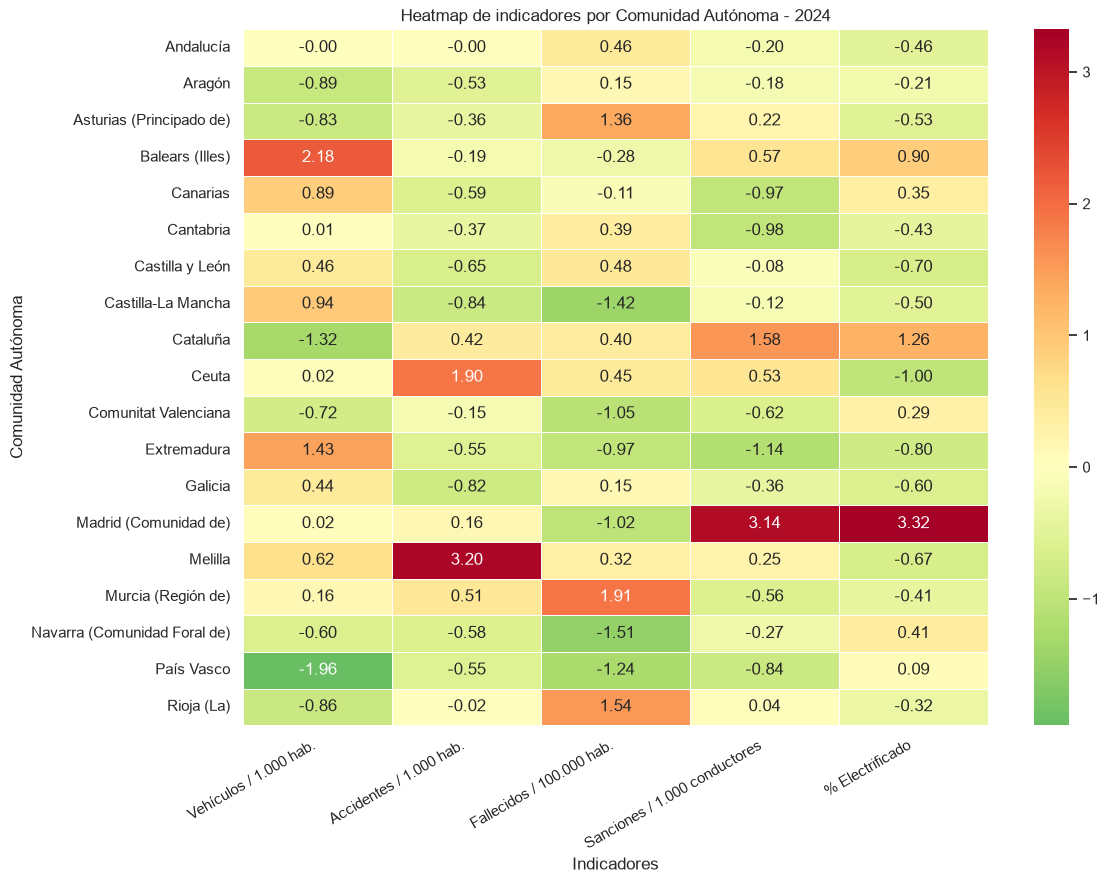

In [28]:
# Heatmap: mapa de calor para ver, en un solo gráfico, la comparación de las comunidades autónomas en los indicadores relativos creados

# Indicadores que queremos comparar
indicadores = [
    "Vehiculos_por_1000_hab",
    "Accidentes_por_1000_hab",
    "Fallecidos_por_100000_hab",
    "Sanciones_por_1000_conductores",
    "Pct_Electrificado"
]

# Seleccionamos las variables
heatmap_ccaa = tabla_ccaa[
    ["Comunidad Autónoma"] + indicadores
].set_index("Comunidad Autónoma")

# Estandarización: z-score
heatmap_z = (
    heatmap_ccaa - heatmap_ccaa.mean()
) / heatmap_ccaa.std()

# Renombramos las columnas para que sean más legibles
heatmap_z.columns = [
    "Vehículos / 1.000 hab.",
    "Accidentes / 1.000 hab.",
    "Fallecidos / 100.000 hab.",
    "Sanciones / 1.000 conductores",
    "% Electrificado"
]

# Heatmap
plt.figure(figsize=(12, 9))

sns.heatmap(
    heatmap_z,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    center=0,
    linewidths=0.5
)

plt.title(f"Heatmap de indicadores por Comunidad Autónoma - {año_ranking}")
plt.xlabel("Indicadores")
plt.ylabel("Comunidad Autónoma")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

guardar_grafico(f"heatmap_CCAA_{año_ranking}")

## Nivel 3: Municipios

¿Qué características tienen los municipios con mayor/menor siniestralidad? ¿Cómo varían las diferencias entre los municipios a lo largo de los años? 
Para responder algunas preguntas acerca de los municipios, creamos nuevas variables agrupando las sanciones, indicadores relativos para poder comparar municipios y tablas con estadísticos descriptivos para algunas variables clave a lo largo de los años.

Obtenemos un fichero con 90156 filas y 102 columnas
RangeIndex: 90156 entries, 0 to 90155
Columns: 102 entries, Año to Pct_Electrificado

In [29]:
# Creamos nuevas columnas que agrupan los tipos de sanciones

dgt_municipal = dgt.copy()

columnas_velocidad = [
    "Velocidad (2 puntos)",
    "Velocidad (3 puntos)",
    "Velocidad (4 puntos)",
    "Velocidad (6 puntos)"
]

dgt_municipal["Sanciones_Velocidad"] = (
    dgt_municipal[columnas_velocidad]
    .sum(axis=1, min_count=1)
)

columnas_alcohol = [
    "Alcohol (4 puntos)",
    "Alcohol (6 puntos)"
]

dgt_municipal["Sanciones_Alcohol"] = (
    dgt_municipal[columnas_alcohol]
    .sum(axis=1, min_count=1)
)

columnas_drogas = [
    "Drogas (6 puntos)"
]

dgt_municipal["Sanciones_Drogas"] = (
    dgt_municipal[columnas_drogas]
    .sum(axis=1, min_count=1)
)

columnas_protección = [
    "Casco, Cinturón, SRI (3 puntos)",
    "Casco, Cinturón, SRI (4 puntos)",
    "Casco, Cinturón, SRI (6 puntos)"
]

dgt_municipal["Sanciones_Proteccion"] = (
    dgt_municipal[columnas_protección]
    .sum(axis=1, min_count=1)
)

columnas_móvil = [
    "Móvil (3 puntos)",
    "Móvil (4 puntos)",
    "Móvil (6 puntos)"
]

dgt_municipal["Sanciones_Movil"] = (
    dgt_municipal[columnas_móvil]
    .sum(axis=1, min_count=1)
)

columnas_semáforo = [
    "Semáforo (3 puntos)",
    "Semáforo (4 puntos)",
    "Semáforo (6 puntos)"
]

dgt_municipal["Sanciones_Semaforo"] = (
    dgt_municipal[columnas_semáforo]
    .sum(axis=1, min_count=1)
)

columnas_otra = [
    "Otra (3 puntos)",
    "Otra (4 puntos)",
    "Otra (6 puntos)"
]

dgt_municipal["Sanciones_Otras"] = (
    dgt_municipal[columnas_otra]
    .sum(axis=1, min_count=1)
)



In [30]:
# Determinamos las variables que queremos analizar 

variables_analisis = [
    "Población Total",
    "Censo Conductores",
    "Parque Total",
    "Antigüedad Media del Parque (<25 años)",
    "Electrificado",
    "Total Puntos Detraídos",
    "Total Sanciones con Puntos",
    "Sanciones_Velocidad",
    "Sanciones_Alcohol",
    "Sanciones_Drogas",
    "Sanciones_Proteccion",
    "Sanciones_Movil",
    "Sanciones_Semaforo",
    "Sanciones_Otras",
    "Nº Accidentes con Víctimas",
    "Fallecidos"
]



In [31]:
# Filtramos para quedarnos los municipios con más de 1.000 y 5.000 habitantes de cara al análisis

# Filtrar municipios con más de 5.000 habitantes
dgt_municipal_5000 = dgt_municipal[
    dgt_municipal["Población Total"] > 5000
].copy()

# Filtrar municipios con más de 1.000 habitantes
dgt_municipal_1000 = dgt_municipal[
    dgt_municipal["Población Total"] > 1000
].copy()

#dgt_municipal_5000.groupby("Año")["Total Puntos Detraídos"].describe().round(2)

In [32]:
# Creamos tablas descriptivas para las variables que más nos interesan, teniendo en cuenta todos los municipios

for variable in variables_analisis:
    print(f"\n{'='*70}")
    print(variable)
    print(f"{'='*70}")
    
    display(
        dgt_municipal
        .groupby("Año")[variable]
        .describe()
        .round(2)
    )



Población Total


,count,mean,std,min,25%,50%,75%,max
Año,,,,,,,,
2014,8117.0,5762.15,46432.79,3.0,166.0,556.0,2443.00,3165235.0
2015,8119.0,5742.63,46215.35,5.0,166.0,549.0,2427.50,3141991.0
2016,8125.0,5730.09,46406.67,5.0,162.0,540.0,2410.00,3165541.0
2017,8124.0,5732.66,46618.00,5.0,159.0,531.0,2407.25,3182981.0
2018,8124.0,5751.23,47002.19,5.0,156.0,525.0,2389.00,3223334.0
2019,8131.0,5783.57,47494.17,3.0,154.5,525.0,2392.00,3266126.0
2020,8131.0,5835.79,48297.07,3.0,152.0,518.0,2394.50,3334730.0
2021,8131.0,5827.71,47845.72,3.0,153.0,523.0,2416.00,3305408.0
2022,8131.0,5838.82,47633.27,3.0,153.0,527.0,2433.50,3280782.0



Censo Conductores


,count,mean,std,min,25%,50%,75%,max
Año,,,,,,,,
2014,8160.0,3212.89,24379.37,1.0,86.0,305.5,1400.00,1632722.0
2015,8164.0,3227.59,24468.72,1.0,85.0,304.0,1410.50,1641789.0
2016,8162.0,3248.47,24611.63,1.0,84.0,302.0,1419.25,1654640.0
2017,8163.0,3264.66,24773.21,1.0,84.0,301.0,1430.00,1671246.0
2018,8165.0,3288.89,24952.20,1.0,83.0,301.0,1434.00,1687222.0
2019,8163.0,3345.71,25366.24,1.0,84.0,305.0,1464.50,1718025.0
2020,8164.0,3332.44,25117.90,1.0,83.0,303.0,1462.00,1700602.0
2021,8162.0,3360.40,25214.78,1.0,82.0,303.0,1478.75,1707075.0
2022,8170.0,3386.06,25330.77,1.0,82.0,304.0,1486.75,1716513.0



Parque Total


...

,count,mean,std,min,25%,50%,75%,max
Año,,,,,,,,
2014,1191.0,217.21,1507.38,0.0,8.00,30.0,104.00,43470.0
2015,1276.0,205.30,1493.66,0.0,7.75,26.0,92.00,47543.0
2016,1286.0,101.88,618.76,0.0,4.00,20.0,68.00,19628.0
2017,1316.0,103.26,563.14,0.0,6.00,22.0,70.00,18690.0
2018,1319.0,119.29,810.19,0.0,6.00,22.0,70.00,27990.0
2019,1350.0,116.38,758.67,0.0,6.00,24.0,76.00,26352.0
2020,1355.0,98.77,492.03,0.0,6.00,24.0,70.00,16329.0
2021,1423.0,124.03,633.82,0.0,8.00,28.0,93.50,21845.0
2022,1454.0,189.37,1037.81,0.0,8.00,30.0,110.75,34256.0



Nº Accidentes con Víctimas


,count,mean,std,min,25%,50%,75%,max
Año,,,,,,,,
2014,6677.0,8.45,161.30,0.0,0.0,0.0,0.0,9565.0
2015,6645.0,9.51,168.12,0.0,0.0,0.0,1.0,9711.0
2016,6849.0,9.58,173.06,0.0,0.0,0.0,1.0,10190.0
2017,6948.0,9.32,173.49,0.0,0.0,0.0,1.0,10406.0
2018,6990.0,9.21,175.56,0.0,0.0,0.0,0.0,10679.0
2019,7018.0,9.51,176.68,0.0,0.0,0.0,1.0,10662.0
2020,7009.0,6.61,114.21,0.0,0.0,0.0,0.0,6806.0
2021,7035.0,8.26,139.86,0.0,0.0,0.0,1.0,8313.0
2022,7049.0,9.17,152.54,0.0,0.0,0.0,1.0,9286.0



Fallecidos


,count,mean,std,min,25%,50%,75%,max
Año,,,,,,,,
2014,6677.0,0.07,0.78,0.0,0.0,0.0,0.0,40.0
2015,6645.0,0.07,0.69,0.0,0.0,0.0,0.0,32.0
2016,6849.0,0.08,0.87,0.0,0.0,0.0,0.0,48.0
2017,6948.0,0.07,0.68,0.0,0.0,0.0,0.0,36.0
2018,6990.0,0.07,0.81,0.0,0.0,0.0,0.0,51.0
2019,7018.0,0.07,0.82,0.0,0.0,0.0,0.0,48.0
2020,7009.0,0.06,0.68,0.0,0.0,0.0,0.0,44.0
2021,7035.0,0.06,0.63,0.0,0.0,0.0,0.0,36.0
2022,7049.0,0.07,0.64,0.0,0.0,0.0,0.0,28.0


In [33]:

# Creamos nuevas columnas para poder hacer una comparación a partir de indicadores relativos

# Vehículos por cada 1.000 habitantes
dgt_municipal["Vehiculos_por_1000_hab"] = (
    dgt_municipal["Parque Total"]
    / dgt_municipal["Población Total"]
    * 1000
)

# Accidentes por cada 1.000 habitantes
dgt_municipal["Accidentes_por_1000_hab"] = (
    dgt_municipal["Nº Accidentes con Víctimas"]
    / dgt_municipal["Población Total"]
    * 1000
)

# Fallecidos por cada 100.000 habitantes,
dgt_municipal["Fallecidos_por_100000_hab"] = (
    dgt_municipal["Fallecidos"]
    / dgt_municipal["Población Total"]
    * 100000
)


# Sanciones por cada 1.000 conductores
dgt_municipal["Sanciones_por_1000_conductores"] = (
    dgt_municipal["Total Sanciones con Puntos"]
    / dgt_municipal["Censo Conductores"]
    * 1000
)


# Accidentes por cada 1.000 vehículos
dgt_municipal["Accidentes_por_1000_veh"] = (
    dgt_municipal["Nº Accidentes con Víctimas"]
    / dgt_municipal["Parque Total"]
    * 1000
)


# Puntos detraídos por sanción
dgt_municipal["Puntos_por_sancion"] = (
    dgt_municipal["Total Puntos Detraídos"]
    / dgt_municipal["Total Sanciones con Puntos"]
    * 1000
)


# Porcentaje de parque electrificado
dgt_municipal["Pct_Electrificado"] = (
    dgt_municipal["Electrificado"]
    / dgt_municipal["Parque Total"]
    * 100
)





In [34]:
# Guardamos el fichero de municipios con las nuevas columnas

dgt_municipal.info()

ruta_municipios = carpeta / "dgt_mun_2014_2024.xlsx"

dgt_municipal.to_excel(
    ruta_municipios,
    index=False
)

print(f"Fichero guardado en: {ruta_municipios}")

<class 'pandas.DataFrame'>
RangeIndex: 90156 entries, 0 to 90155
Columns: 104 entries, Año to Pct_Electrificado
dtypes: float64(99), int64(2), str(3)
memory usage: 71.5 MB
Fichero guardado en: C:\Users\U000000\Desktop\varios\ThePower\PROYECTO_FINAL\datos\dgt_mun_2014_2024.xlsx


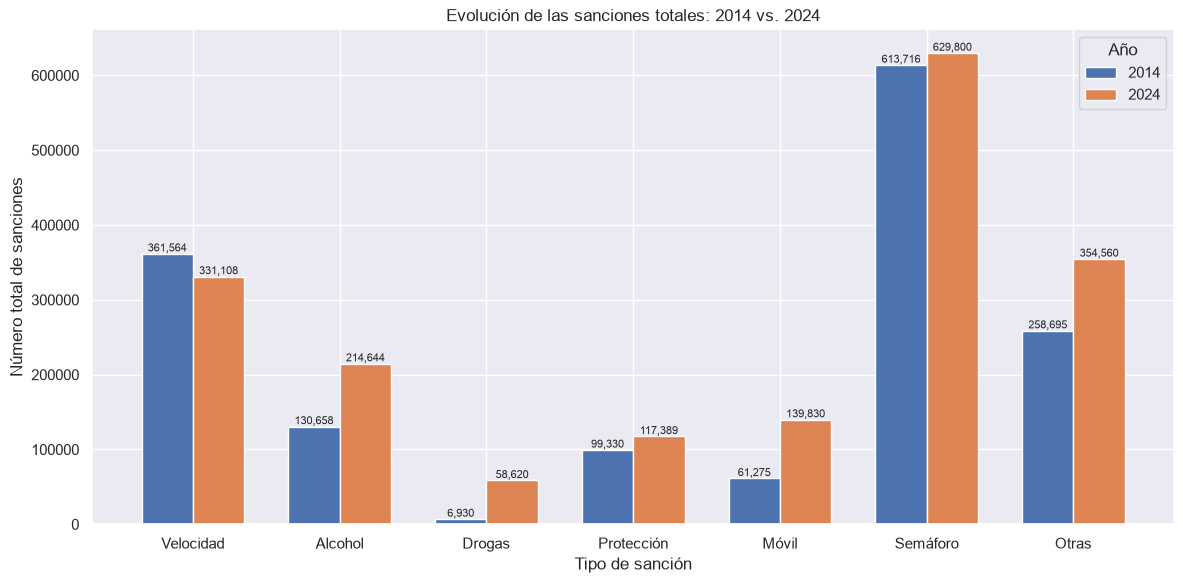

In [35]:
#Gráfico de barras que muestra, para 2014 y 2024, las sanciones totales por tipo.

# Columnas de sanciones
columnas_sanciones = [
    "Sanciones_Velocidad",
    "Sanciones_Alcohol",
    "Sanciones_Drogas",
    "Sanciones_Proteccion",
    "Sanciones_Movil",
    "Sanciones_Semaforo",
    "Sanciones_Otras"
]

# Filtrar 2014 y 2024 y sumar las sanciones de cada tipo
totales = dgt_municipal[dgt_municipal["Año"].isin([2014, 2024])].groupby("Año")[columnas_sanciones].sum()

# Cambiar nombres para que aparezcan más limpios en el gráfico
nombres = [
    "Velocidad",
    "Alcohol",
    "Drogas",
    "Protección",
    "Móvil",
    "Semáforo",
    "Otras"
]

# Posiciones de las categorías
x = np.arange(len(nombres))
ancho = 0.35

# Crear gráfico
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - ancho/2, totales.loc[2014], ancho, label="2014")
ax.bar(x + ancho/2, totales.loc[2024], ancho, label="2024")


# Configuración
ax.set_xlabel("Tipo de sanción")
ax.set_ylabel("Número total de sanciones")
ax.set_title("Evolución de las sanciones totales: 2014 vs. 2024")

ax.set_xticks(x)
ax.set_xticklabels(nombres)
ax.legend(title="Año")

# Valores encima de las barras
for i, valor in enumerate(totales.loc[2014]):
    ax.text(i - ancho/2, valor, f"{valor:,.0f}",
            ha="center", va="bottom", fontsize=8)

for i, valor in enumerate(totales.loc[2024]):
    ax.text(i + ancho/2, valor, f"{valor:,.0f}",
            ha="center", va="bottom", fontsize=8)

plt.tight_layout()

guardar_grafico("sanciones")

### Análisis bivariante

- ¿Se relacionan las sanciones con la siniestralidad?
- ¿Las campañas están asociadas con más sanciones o menos accidentes?
- ¿Influye la antigüedad del parque?
- ¿Son distintos los resultados según el tamaño municipal?
- ¿Cómo evolucionan los municipios entre 2014 y 2024?

Vamos a intentar responder estas preguntas a continuación


In [42]:
# Determinamos las variables que queremos tener en cuenta en el análisis

variables_relacion = [
    "Antigüedad Media del Parque (<25 años)",
    "Vehiculos_por_1000_hab",
    "Accidentes_por_1000_hab",
    "Fallecidos_por_100000_hab",
    "Sanciones_por_1000_conductores",
    # "Accidentes_por_1000_veh",
    "Puntos_por_sancion",
    "Pct_Electrificado"
]

# Comprobamos que todas las variables existen

[column for column in variables_relacion if column not in dgt_municipal.columns]


[]

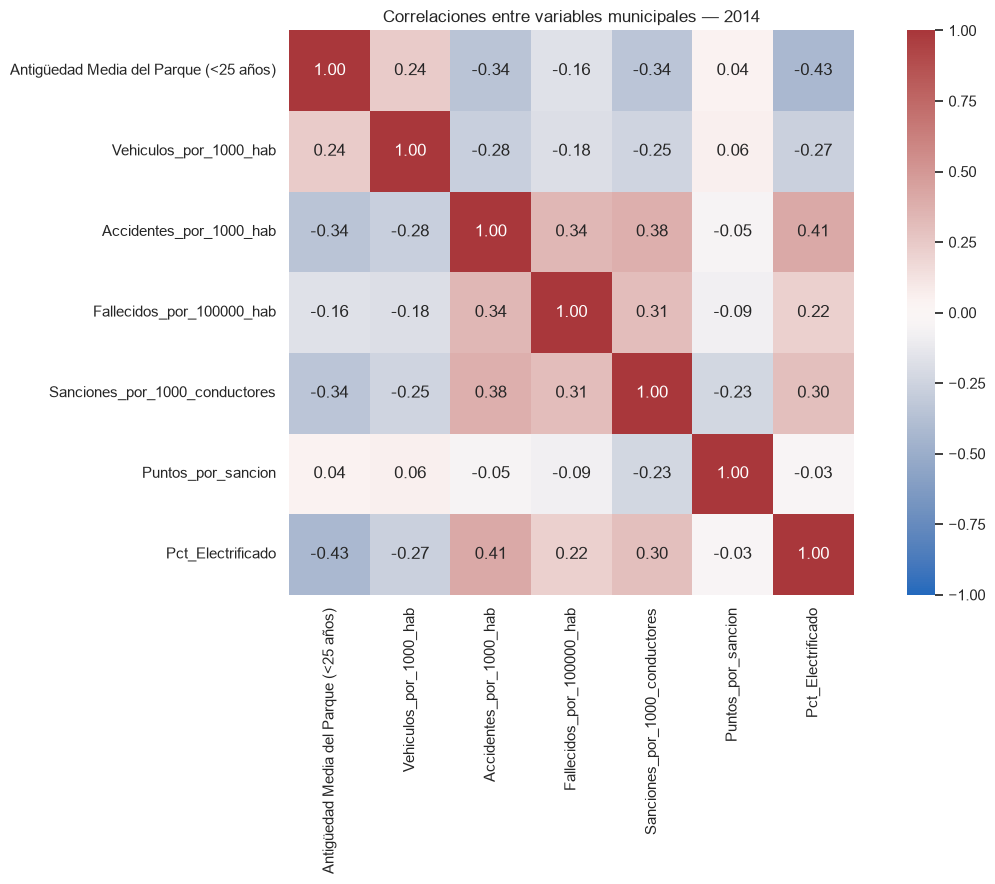

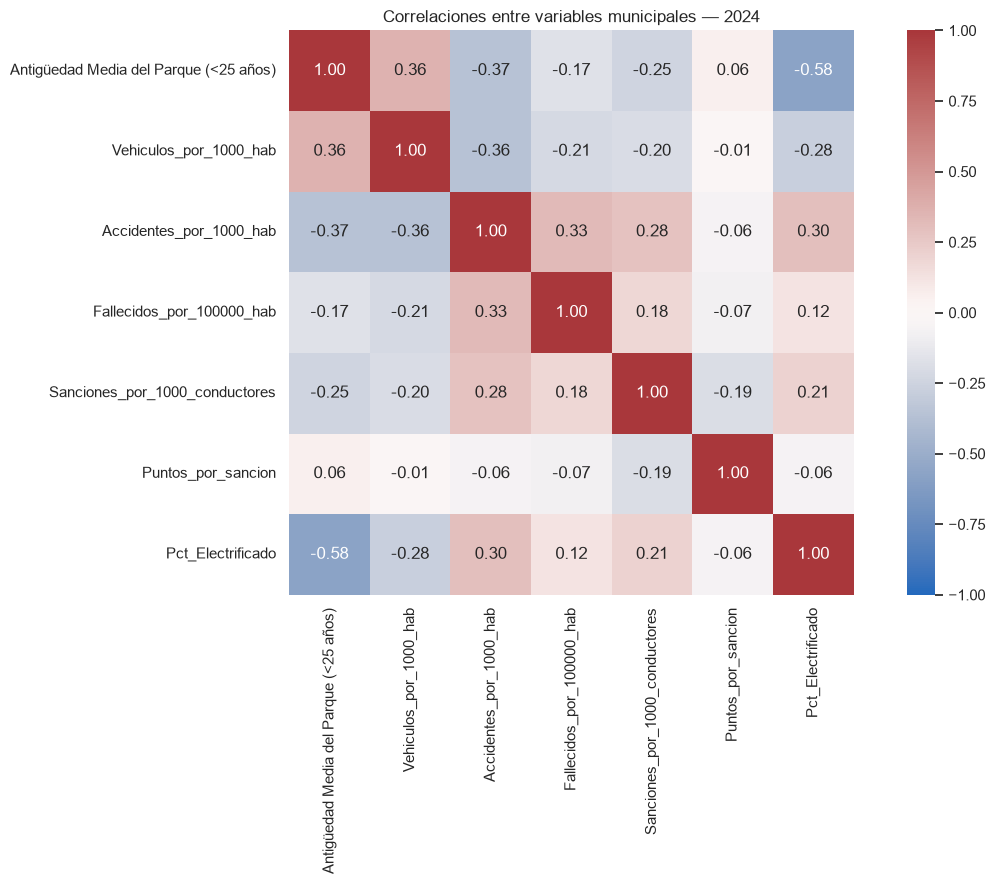

In [43]:
# Creamos una función heatmap de correlaciones para un año

def heatmap_correlaciones_por_año(df, año, variables):
    datos = df.loc[df["Año"] == año, variables]
    correlaciones = datos.corr(method="spearman")

    plt.figure(figsize=(12, 9))
    sns.heatmap(
        correlaciones,
        annot=True,
        fmt=".2f",
        cmap="vlag",
        center=0,
        vmin=-1,
        vmax=1,
        square=True
    )

    plt.title(f"Correlaciones entre variables municipales — {año}")
    plt.tight_layout()
    guardar_grafico(f"correlaciones_{año}_spearman")

heatmap_correlaciones_por_año(dgt_municipal, 2014, variables_relacion)
heatmap_correlaciones_por_año(dgt_municipal, 2024, variables_relacion)


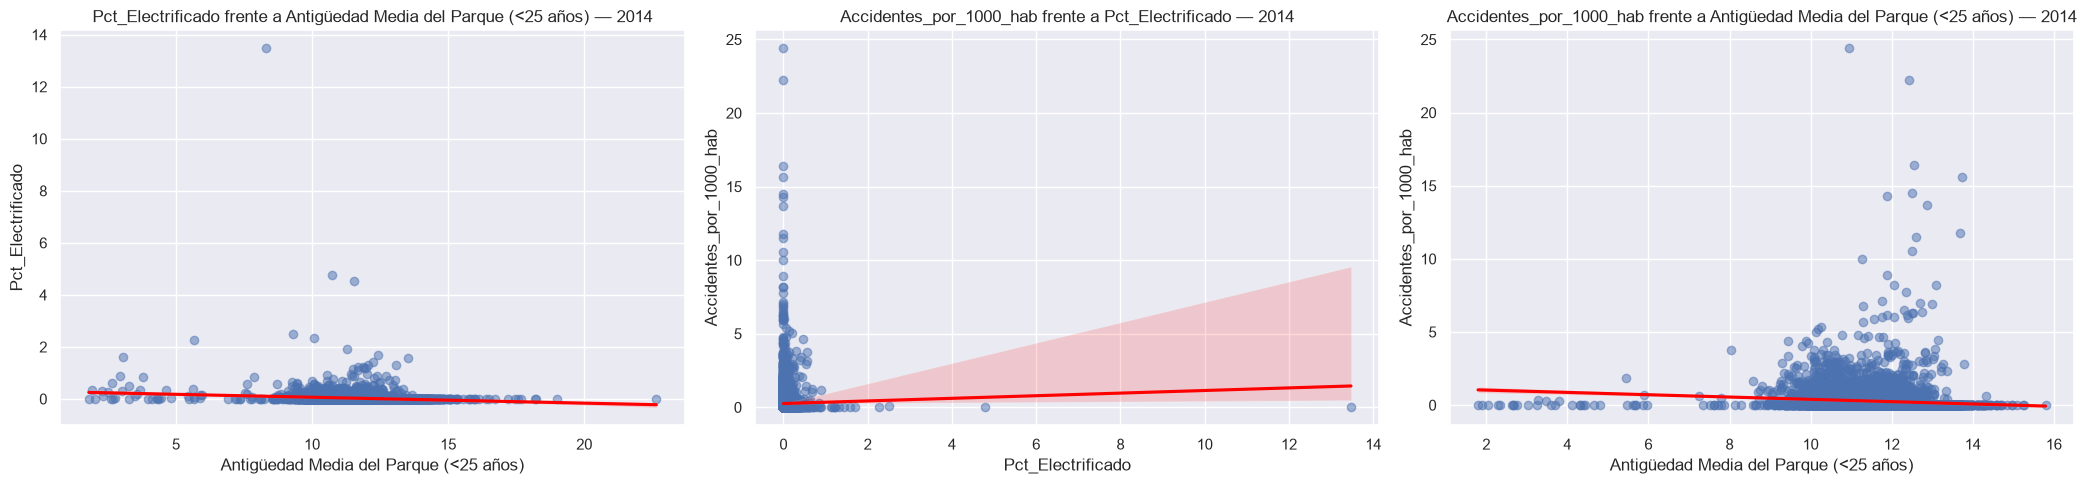

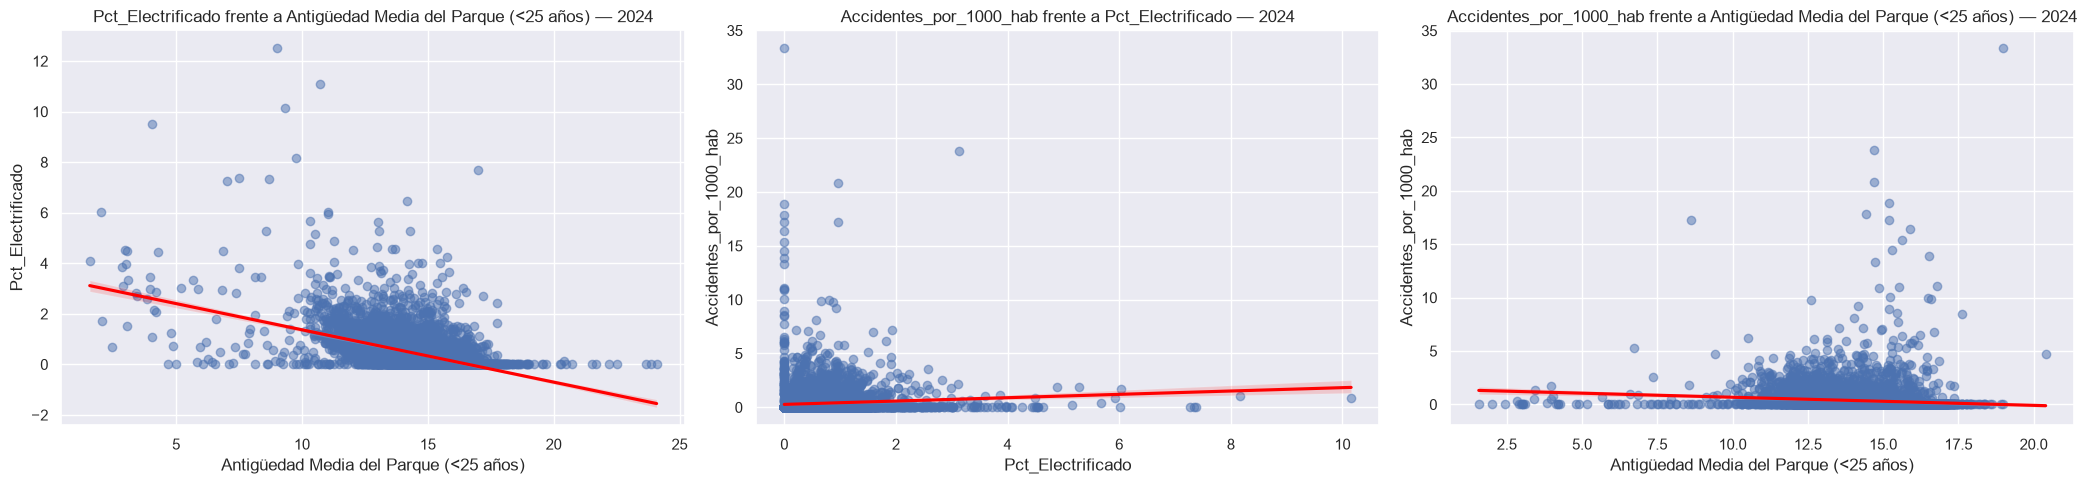

In [47]:
# Continuamos el análisis con diagramas de dispersión para las relaciones más destacadas

pares = [
    ("Antigüedad Media del Parque (<25 años)", "Pct_Electrificado"),
    ("Pct_Electrificado", "Accidentes_por_1000_hab"),
    ("Antigüedad Media del Parque (<25 años)", "Accidentes_por_1000_hab")
]
    

def graficos_correlacion_por_ano(datos, pares, año):
    datos_año = datos.loc[datos["Año"] == año]

    fig, axes = plt.subplots(
        1, len(pares),
        figsize=(7 * len(pares), 5)
    )

    # Si solo hubiera un gráfico, convertir axes en lista
    if len(pares) == 1:
        axes = [axes]

    for ax, (x, y) in zip(axes, pares):
        sns.regplot(
            data=datos_año,
            x=x,
            y=y,
            ax=ax,
            scatter_kws={"alpha": 0.5},
            line_kws={"color": "red"}
        )

        ax.set_title(f"{y} frente a {x} — {año}")

    plt.tight_layout()
    guardar_grafico(f"dispersion_{año}")
    
graficos_correlacion_por_ano(dgt_municipal, pares, 2014)
graficos_correlacion_por_ano(dgt_municipal, pares, 2024)

In [60]:
# Dado que no se observan con claridad relaciones entre las variables, vamos a estudiar si, agrupando los municipios en 4 grupos, obtenemos más información.

def agrupar_municipios(datos, año):
    
    # Seleccionar únicamente el año indicado
    df = datos.loc[datos["Año"] == año].copy()

    # Crear grupos de población
    df["Grupo_tamaño"] = pd.cut(
        df["Población Total"],
        bins=[-float("inf"), 500, 5000, 20000, float("inf")],
        labels=[
            "< 500",
            "500–5.000",
            "5.000–20.000",
            "> 20.000"
        ],
        right=False
    )

    # Resumen de los grupos
    resumen = (
        df.groupby("Grupo_tamaño", observed=False)["Población Total"]
        .agg(
            Municipios="count",
            Mínimo="min",
            Máximo="max",
            Media="mean",
            Mediana="median"
        )
        .reset_index()
    )

    # Porcentaje de municipios de cada grupo
    resumen["Porcentaje"] = (
        resumen["Municipios"] /
        resumen["Municipios"].sum() * 100
    ).round(2)

    # Redondear estadísticas de población
    resumen["Media"] = resumen["Media"].round(0)
    resumen["Mediana"] = resumen["Mediana"].round(0)

    print(f"\nDistribución de municipios por tamaño — {año}")
    print(resumen.to_string(index=False))

    return df, resumen

datos_2024, resumen_2024 = agrupar_municipios(dgt_municipal, año=2024)
datos_2024, resumen_2024 = agrupar_municipios(dgt_municipal, año=2014)


Distribución de municipios por tamaño — 2024
Grupo_tamaño  Municipios  Mínimo    Máximo   Media  Mediana  Porcentaje
       < 500        3976     2.0     499.0   182.0    148.0       48.90
   500–5.000        2832   500.0    4995.0  1764.0   1347.0       34.83
5.000–20.000         894  5006.0   19915.0  9813.0   8646.0       10.99
    > 20.000         429 20016.0 3422416.0 79544.0  35910.0        5.28

Distribución de municipios por tamaño — 2014
Grupo_tamaño  Municipios  Mínimo    Máximo   Media  Mediana  Porcentaje
       < 500        3877     3.0     499.0   189.0    158.0       47.76
   500–5.000        2936   500.0    4997.0  1754.0   1346.0       36.17
5.000–20.000         905  5001.0   19992.0  9846.0   8645.0       11.15
    > 20.000         399 20029.0 3165235.0 80143.0  36180.0        4.92


In [ ]:
# Creamos una función de heatmaps teniendo en cuenta la división de los municipios por tamaño, por años
# Hacemos 4 grupos: "< 500", "500–5.000", "5.000–20.000", "> 20.000"
def heatmaps_tamaño(
    df,
    año,
    variables,
    columna_poblacion="Población Total"
):
    
    # Seleccionar el año
    datos = df.loc[df["Año"] == año].copy()

    # Crear grupos de tamaño
    df["Grupo_tamaño"] = pd.cut(
        df[columna_poblacion],
        bins=[-float("inf"), 500, 5000, 20000, float("inf")],
        labels=[
            "< 500",
            "500–5.000",
            "5.000–20.000",
            "> 20.000"
        ],
        right=False
    )

    # Crear una figura con un heatmap por grupo
    fig, axes = plt.subplots(
        2, 2,
        figsize=(16, 13)
    )

    axes = axes.flatten()

    correlaciones = {}

    for ax, grupo in zip(axes, datos["Grupo_tamaño"].cat.categories):

        datos_grupo = datos.loc[
            datos["Grupo_tamaño"] == grupo,
            variables
        ]

        # Matriz de correlaciones de Spearman
        corr = datos_grupo.corr(method="spearman")

        correlaciones[grupo] = corr

        # Heatmap
        sns.heatmap(
            corr,
            annot=True,
            fmt=".2f",
            cmap="vlag",
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            ax=ax
        )

        n_municipios = len(datos_grupo)

        ax.set_title(
            f"{grupo} habitantes\n"
            f"(n = {n_municipios})"
        )

    fig.suptitle(
        f"Correlaciones de Spearman por tamaño municipal — {año}",
        fontsize=16
    )

    plt.tight_layout()
    guardar_grafico(f"correlaciones_tamaños_{año}")

    return correlaciones

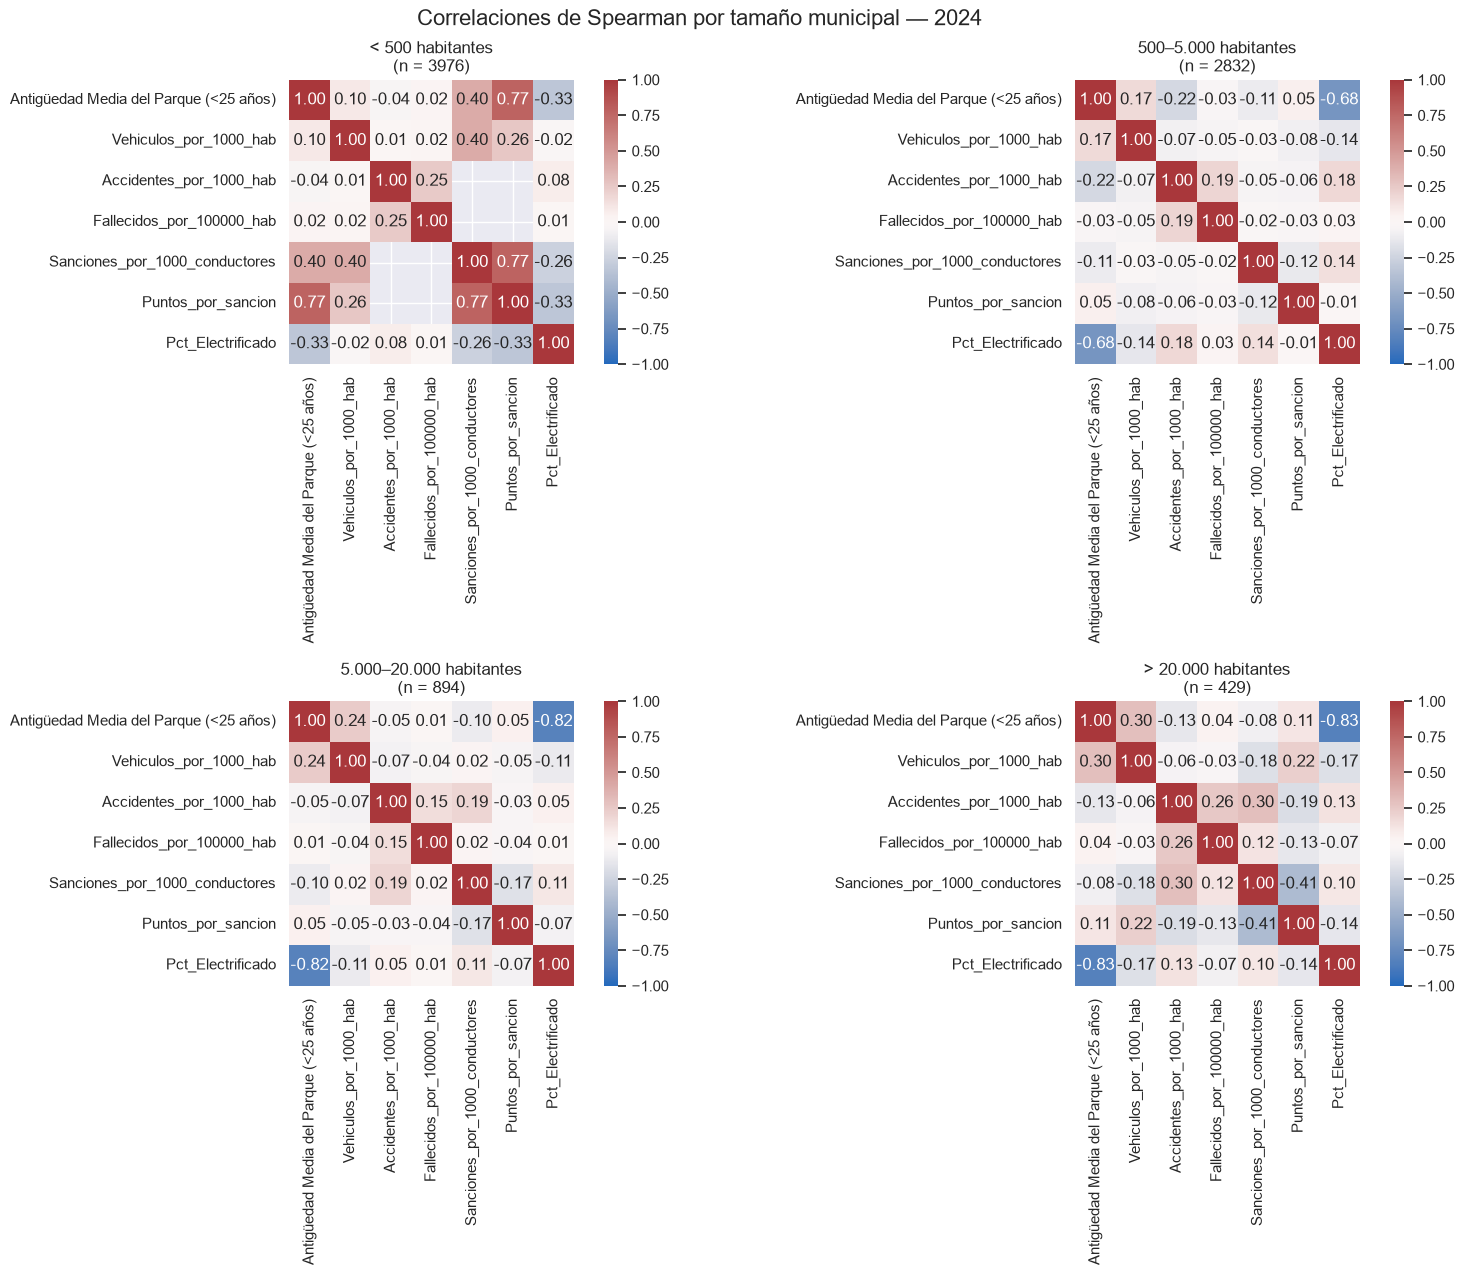

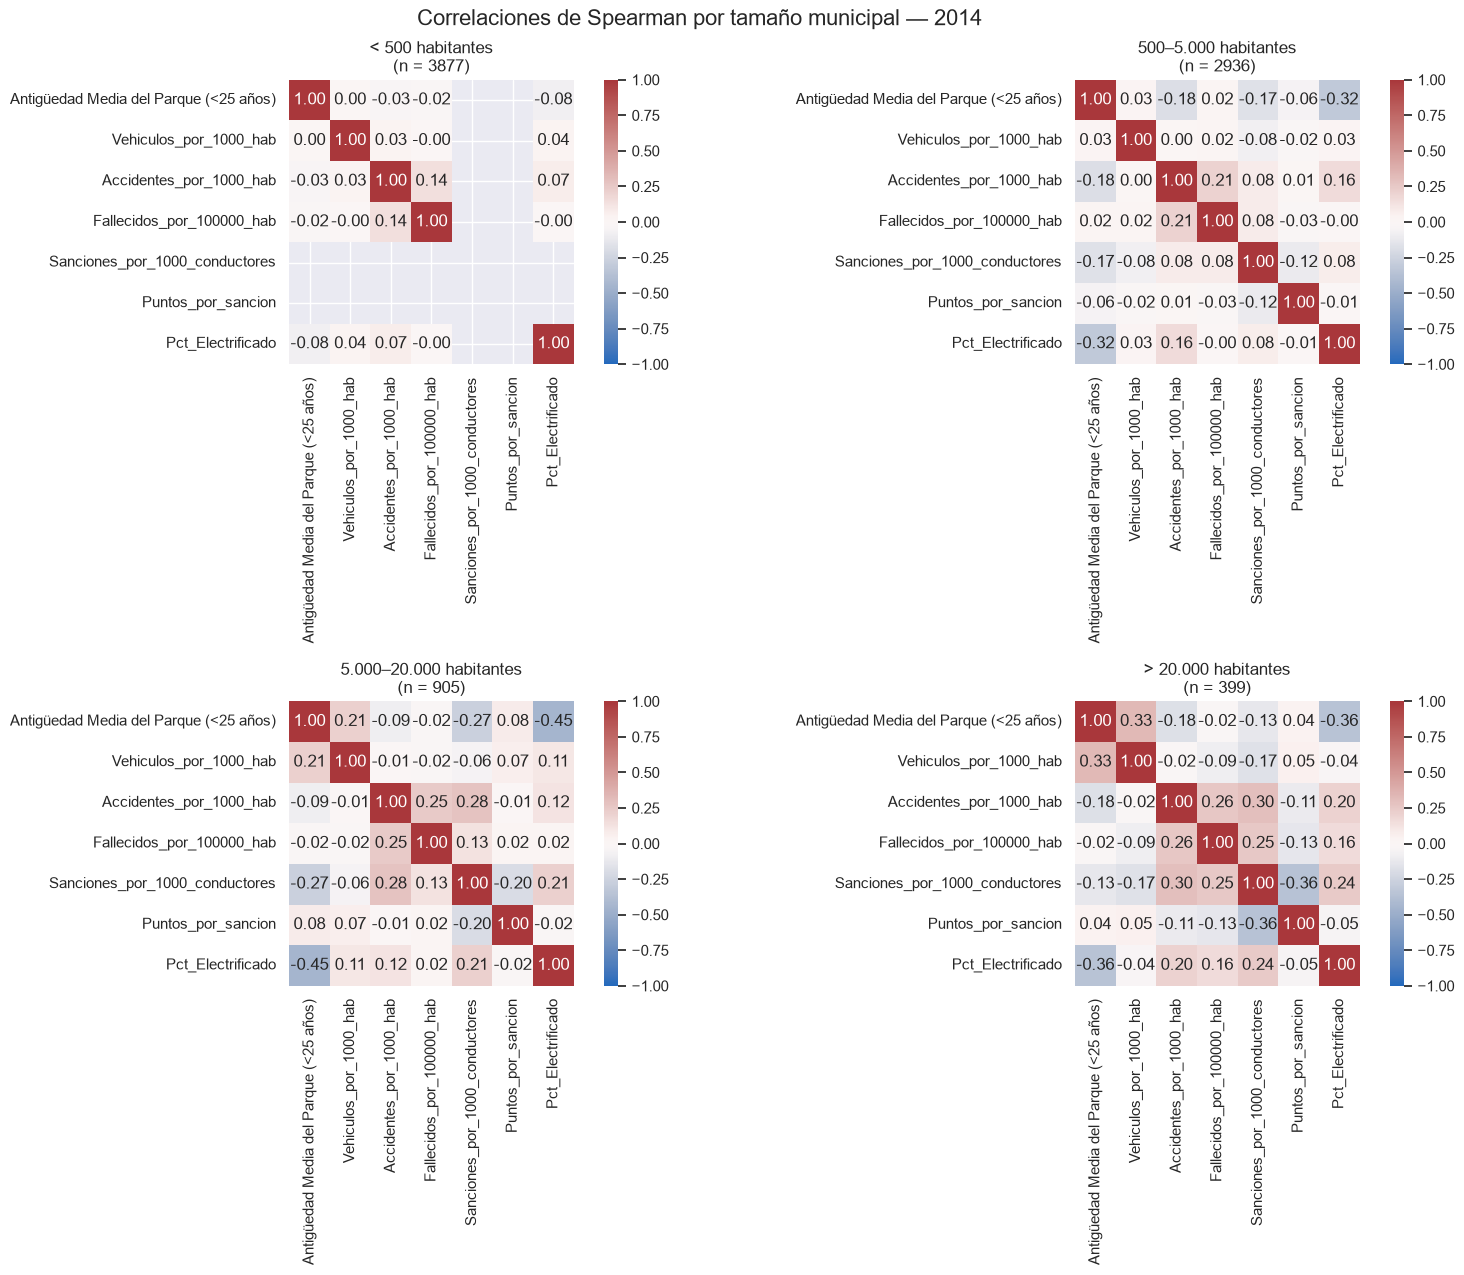

In [ ]:
# Llamamos a la función para los años 2014 y 2024

corr_2024 = heatmaps_tamaño(
    dgt_municipal,
    año=2024,
    variables=variables_relacion,
    columna_poblacion="Población Total"
)

corr_2014 = heatmaps_tamaño(
    dgt_municipal,
    año=2014,
    variables=variables_relacion,
    columna_poblacion="Población Total"
)
